

*   The dataset is taken from kaggle.
*   The dataset is an automobile insurance dataset “carclaims”, which is publically available and is provided by Angoss Knowledge Seeker. It has 15420 samples, of which 14497 are legitimate and 923 fraudulent, which indicates high class imbalance.




In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
khusheekapoor_vehicle_insurance_fraud_detection_path = kagglehub.dataset_download('khusheekapoor/vehicle-insurance-fraud-detection')

print('Data source import complete.')


100%|██████████| 349k/349k [00:00<00:00, 585kB/s]

Extracting files...
Data source import complete.


In [ ]:
import os

path = khusheekapoor_vehicle_insurance_fraud_detection_path
print(os.listdir(path))

['carclaims.csv']


* Data Handling: Pandas & NumPy for structured data and math.

* Visualization: Matplotlib & Seaborn for identifying patterns/outliers.

* Preprocessing: StandardScaler (scaling) and train_test_split (validation).

* Balancing: SMOTE/ADASYN to fix minority class bias.

* Modeling: Comparison of SVM, Random Forest, and KNN.

* Tuning: GridSearchCV/RandomizedSearchCV for finding optimal parameters.

* Evaluation: Confusion Matrix and ROC-AUC to measure real-world performance.

In [ ]:
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint


# Train-test split & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from scipy import stats


# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV



# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Imbalanced learning
from imblearn.over_sampling import SMOTE, ADASYN

Loaded the carclaims.csv dataset using Pandas. The .head() function displays the first five rows to verify data integrity and understand initial feature types (e.g., categorical vs. numerical).

In [ ]:
df = pd.read_csv(khusheekapoor_vehicle_insurance_fraud_detection_path + "/carclaims.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (15420, 33)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber          15420 non-null

In [ ]:
df.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [ ]:
df['FraudFound'].value_counts()

,count
FraudFound,
No,14497
Yes,923


In [ ]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [ ]:
df.dtypes

,0
Month,object
WeekOfMonth,int64
DayOfWeek,object
Make,object
AccidentArea,object
DayOfWeekClaimed,object
MonthClaimed,object
WeekOfMonthClaimed,int64
Sex,object
MaritalStatus,object


Text(0, 0.5, 'Number of Cases')

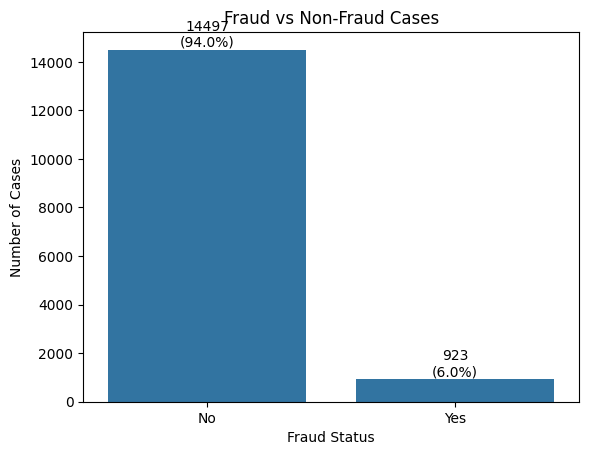

In [ ]:
# bar chart for class imbalance with percentage
ax = sns.countplot(x = "FraudFound" , data = df)

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom')

plt.title("Fraud vs Non-Fraud Cases")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Cases")

In [ ]:
pprint(df.columns.tolist())

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'WeekOfMonthClaimed',
 'Sex',
 'MaritalStatus',
 'Age',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days:Policy-Accident',
 'Days:Policy-Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange-Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy',
 'FraudFound']


In [ ]:
drop_cols = [
'PolicyNumber',
'RepNumber',
'MonthClaimed',
'DayOfWeekClaimed',
'WeekOfMonthClaimed'
]

df = df.drop(columns=drop_cols)

In [ ]:
pprint(df.columns.tolist())

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'Sex',
 'MaritalStatus',
 'Age',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'Deductible',
 'DriverRating',
 'Days:Policy-Accident',
 'Days:Policy-Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange-Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy',
 'FraudFound']


In [ ]:
# one hot encoding
df = pd.get_dummies(df, drop_first=True)

In [ ]:
pprint(df.columns.tolist())

['WeekOfMonth',
 'Age',
 'Deductible',
 'DriverRating',
 'Year',
 'Month_Aug',
 'Month_Dec',
 'Month_Feb',
 'Month_Jan',
 'Month_Jul',
 'Month_Jun',
 'Month_Mar',
 'Month_May',
 'Month_Nov',
 'Month_Oct',
 'Month_Sep',
 'DayOfWeek_Monday',
 'DayOfWeek_Saturday',
 'DayOfWeek_Sunday',
 'DayOfWeek_Thursday',
 'DayOfWeek_Tuesday',
 'DayOfWeek_Wednesday',
 'Make_BMW',
 'Make_Chevrolet',
 'Make_Dodge',
 'Make_Ferrari',
 'Make_Ford',
 'Make_Honda',
 'Make_Jaguar',
 'Make_Lexus',
 'Make_Mazda',
 'Make_Mecedes',
 'Make_Mercury',
 'Make_Nisson',
 'Make_Pontiac',
 'Make_Porche',
 'Make_Saab',
 'Make_Saturn',
 'Make_Toyota',
 'Make_VW',
 'AccidentArea_Urban',
 'Sex_Male',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'MaritalStatus_Widow',
 'Fault_Third Party',
 'PolicyType_Sedan - Collision',
 'PolicyType_Sedan - Liability',
 'PolicyType_Sport - All Perils',
 'PolicyType_Sport - Collision',
 'PolicyType_Sport - Liability',
 'PolicyType_Utility - All Perils',
 'PolicyType_Utility - Collision

In [ ]:
# split input and target
X = df.drop('FraudFound_Yes', axis=1)
y = df['FraudFound_Yes']

In [ ]:
# check
print(y.value_counts())

FraudFound_Yes
False    14497
True       923
Name: count, dtype: int64


In [ ]:
rf = RandomForestClassifier()
rf.fit(X, y)

RandomForestClassifier()

Used a Random Forest Classifier to calculate feature importance. This method ranks variables based on their contribution to reducing impurity (Gini importance) across all decision trees.

Key Actions:
* Fit: Trained the model on features $X$ and target $y$.
* Filter: Identified features with importance $< 0.01$ for potential removal.
* Ranking: Sorted features to isolate the most predictive drivers of fraud.

In [ ]:
# get features with more importance and drop the features with importance < 0.01

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

Age                             9.377184e-02
WeekOfMonth                     5.712327e-02
DriverRating                    5.092974e-02
Year                            3.944507e-02
Fault_Third Party               3.609010e-02
                                    ...     
Days:Policy-Claim_none          1.219643e-05
Make_Jaguar                     9.000483e-06
Make_Lexus                      1.631622e-06
NumberOfCars_more than 8        1.517860e-08
PolicyType_Sport - Liability    0.000000e+00
Length: 102, dtype: float64


In [ ]:
low_features = importance[importance < 0.01].index

df = df.drop(columns=low_features)

In [ ]:
pprint(df.columns.tolist())

['WeekOfMonth',
 'Age',
 'DriverRating',
 'Year',
 'Month_Aug',
 'Month_Feb',
 'Month_Jan',
 'Month_Jun',
 'Month_Mar',
 'Month_May',
 'Month_Oct',
 'Month_Sep',
 'DayOfWeek_Monday',
 'DayOfWeek_Saturday',
 'DayOfWeek_Sunday',
 'DayOfWeek_Thursday',
 'DayOfWeek_Tuesday',
 'DayOfWeek_Wednesday',
 'Make_Chevrolet',
 'Make_Honda',
 'Make_Mazda',
 'Make_Pontiac',
 'Make_Toyota',
 'AccidentArea_Urban',
 'Sex_Male',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'Fault_Third Party',
 'VehiclePrice_30,000 to 39,000',
 'VehiclePrice_more than 69,000',
 'PastNumberOfClaims_2 to 4',
 'PastNumberOfClaims_none',
 'AgeOfVehicle_6 years',
 'AgeOfVehicle_7 years',
 'AgeOfVehicle_more than 7',
 'AgeOfPolicyHolder_31 to 35',
 'AgeOfPolicyHolder_36 to 40',
 'AgeOfPolicyHolder_41 to 50',
 'NumberOfSuppliments_3 to 5',
 'NumberOfSuppliments_more than 5',
 'NumberOfSuppliments_none',
 'FraudFound_Yes']


split the train and test data - 80% train 20% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

SVM : support vector machine
* supervised
* hyperplane in 2D - decision boundary that seperates the classes - wx + b = 0
* classification

Applied StandardScaler to normalize feature distributions. This ensures all variables have a mean of 0 and a standard deviation of 1.

Interpretation:
Models like SVM and KNN calculate distances between data points. Scaling prevents features with larger numerical ranges (e.g., "Income") from dominating features with smaller ranges (e.g., "Age"), ensuring fair mathematical weighting.

https://medium.com/@myselfaman12345/c-and-gamma-in-svm-e6cee48626be

In [ ]:
# 5. Feature Scaling

# SVM is sensitive to feature scale
# StandardScaler normalizes features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Defined a search grid (param_dist) for the Support Vector Machine (SVM) to optimize the $C$ (regularization) and $\gamma$ (influence distance) parameters using the RBF kernel.

Key Parameters:

$C$: Controls the trade-off between a smooth boundary and classifying training points correctly.

$\gamma$: Defines how far the influence of a single training example reaches.

Interpretation:Finding the "sweet spot" for $C$ and $\gamma$ prevents overfitting (high variance) or underfitting (high bias), ensuring the model generalizes well to new insurance claims.

In [ ]:
# 6. Hyperparameter Tuning

param_dist = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

Implemented RandomizedSearchCV to efficiently explore the SVM hyperparameter space. Unlike a full Grid Search, it evaluates a fixed number of random combinations (n_iter=10) using 3-fold Cross-Validation (CV) to ensure result stability.

Key Settings:

probability=True: Enables probability estimates for later AUC-ROC calculation.

n_jobs=-1: Utilizes all available CPU cores for parallel processing (faster training).

verbose=2: Provides real-time progress updates.

Interpretation:
This automated "tuning" finds the most accurate SVM settings while significantly reducing computation time compared to testing every possible combination. Cross-validation ensures the final model isn't just "memorizing" the training data.

In [ ]:
random_search = RandomizedSearchCV(
    SVC(probability=True),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'gamma': [1, 0.1, 0.01],
                                        'kernel': ['rbf']},
                   verbose=2)

In [ ]:
# Best parameters
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'kernel': 'rbf', 'gamma': 1, 'C': 10}


In [ ]:
# Use the best model found by RandomizedSearch
model = random_search.best_estimator_

In [ ]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Probabilities for ROC and PR curves
y_prob = model.predict_proba(X_test_scaled)[:,1]

https://medium.com/analytics-vidhya/confusion-matrix-accuracy-precision-recall-f1-score-ade299cf63cd

In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9364461738002594


In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97      2887
        True       1.00      0.01      0.01       197

    accuracy                           0.94      3084
   macro avg       0.97      0.50      0.49      3084
weighted avg       0.94      0.94      0.91      3084



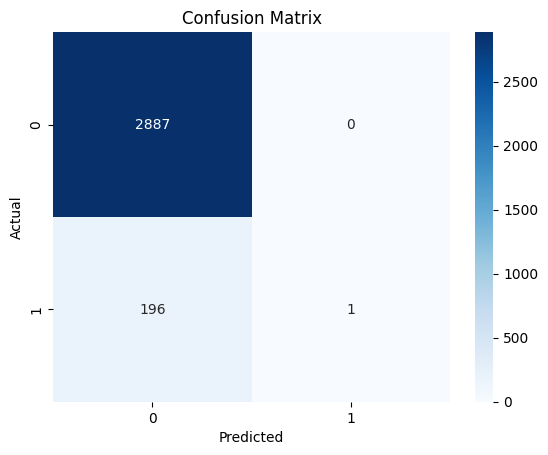

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

https://www.displayr.com/what-is-a-roc-curve-how-to-interpret-it/
https://www.datacamp.com/tutorial/auc

In [ ]:
print("Number of Support Vectors:", model.n_support_)

Number of Support Vectors: [11610   726]


RF

Executed RandomizedSearchCV on a Random Forest Classifier to optimize tree structure and ensemble size. The search space included n_estimators, max_depth, and sample split requirements.

Key Features:

class_weight='balanced': Automatically adjusts weights inversely proportional to class frequencies to handle the fraud imbalance.

n_iter=20: Sampled 20 combinations to find the most efficient model without exhaustive computation.

cv=3: Applied 3-fold cross-validation to ensure the selected parameters are robust across different data subsets.

Interpretation:
Tuning max_depth and min_samples_leaf controls model complexity. This prevents the "forest" from becoming too specific to the training data (overfitting) while ensuring it captures the nuances of fraudulent behavior.

In [ ]:
# Parameter search space

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Randomized Search
random_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Train models
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}


In [ ]:
# Use best model from RandomizedSearch

model = random_search.best_estimator_

# Train final model
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=30, n_estimators=500)

In [ ]:
# Predict labels
y_pred = model.predict(X_test)

# Probability predictions for curves
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9367704280155642


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97      2887
        True       0.67      0.02      0.04       197

    accuracy                           0.94      3084
   macro avg       0.80      0.51      0.50      3084
weighted avg       0.92      0.94      0.91      3084



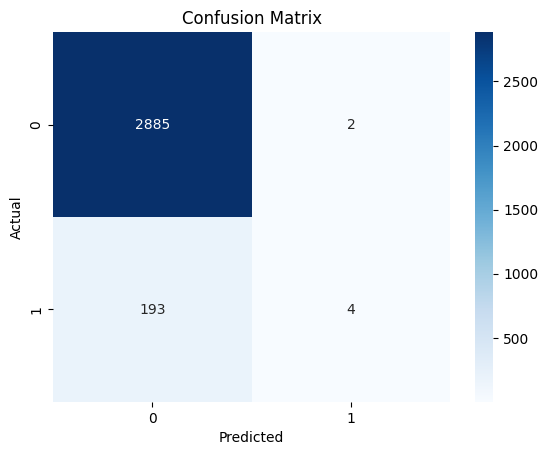

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

KNN

In [ ]:
param_dist = {
    'n_neighbors': [3,5,7,9,11,15],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)   # Note : we are using scaled data as svm and knn are distance based models

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'weights': 'uniform', 'n_neighbors': 15, 'metric': 'euclidean'}


In [ ]:
model = random_search.best_estimator_

model.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=15)

In [ ]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9361219195849546


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97      2887
        True       0.00      0.00      0.00       197

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


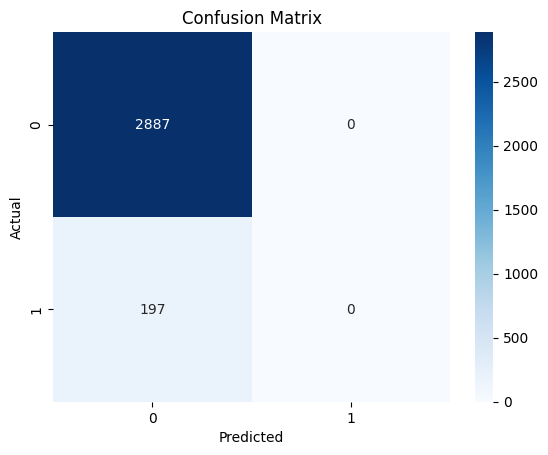

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)  # note:apply smote
#only on the training set

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: FraudFound_Yes
False    11610
True       726
Name: count, dtype: int64
After SMOTE: FraudFound_Yes
False    11610
True     11610
Name: count, dtype: int64


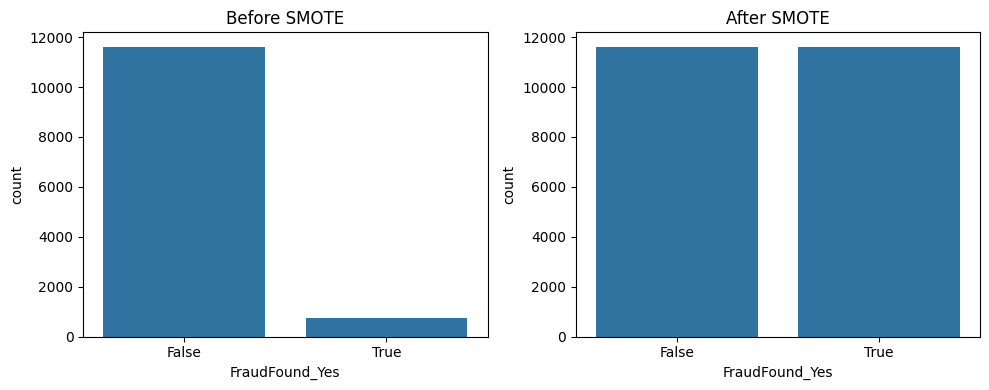

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

In [ ]:
# apply svm on smote applied dataset

#feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

Due to the high computational complexity of SVM with RBF kernel, especially after applying SMOTE, hyperparameter tuning was computationally expensive. Therefore, a reduced parameter search space and optimized configuration were used.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': [1, 10],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf']
}

random_search = RandomizedSearchCV(
    SVC(probability=False),   # IMPORTANT
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 4 candidates, totalling 12 fits


RandomizedSearchCV(cv=3, estimator=SVC(), n_iter=5, n_jobs=-1,
                   param_distributions={'C': [1, 10], 'gamma': [0.1, 0.01],
                                        'kernel': ['rbf']},
                   verbose=2)

In [ ]:
# predictions

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.9361219195849546


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97      2887
        True       0.00      0.00      0.00       197

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


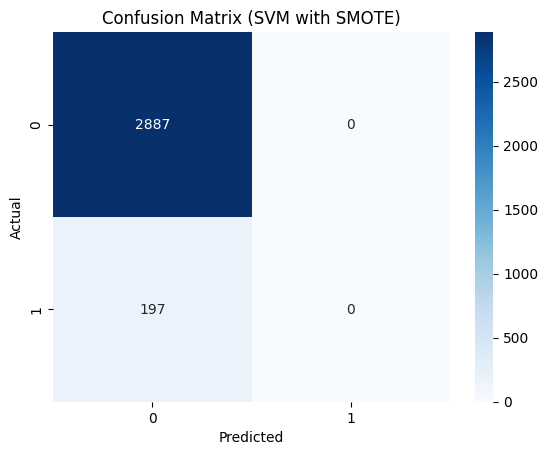

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (SVM with SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
param_dist = {
    'n_estimators': [100,200,300,400,500],
    'max_depth': [None,10,20,30,40],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

In [ ]:
# run the randomized search

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, verbose=2)

In [ ]:
# get the best model

best_rf = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}


In [ ]:
# make the predictions based on the best model

y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:,1]

In [ ]:
# accuracy

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9309338521400778


In [ ]:
# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.99      0.96      2887
        True       0.30      0.06      0.10       197

    accuracy                           0.93      3084
   macro avg       0.62      0.53      0.53      3084
weighted avg       0.90      0.93      0.91      3084



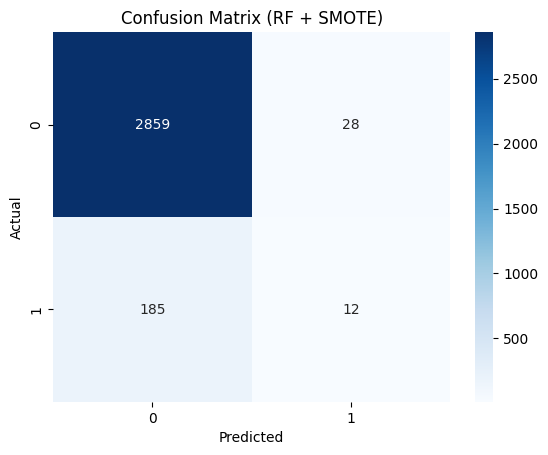

In [ ]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (RF + SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# KNN
# define the hyperparameter space

param_dist = {
    'n_neighbors': [3,5,7,9,11,15,21],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

In [ ]:
# randomized search

knn = KNeighborsClassifier()

random_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train_smote)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3, estimator=KNeighborsClassifier(), n_iter=15, n_jobs=-1,
                   param_distributions={'metric': ['euclidean', 'manhattan'],
                                        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
                                        'weights': ['uniform', 'distance']},
                   random_state=42, verbose=2)

In [ ]:
# get the best model

best_knn = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'weights': 'distance', 'n_neighbors': 3, 'metric': 'euclidean'}


In [ ]:
# predictions

y_pred = best_knn.predict(X_test_scaled)

y_prob = best_knn.predict_proba(X_test_scaled)[:,1]

In [ ]:
# accuracy

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8333333333333334


In [ ]:
# classification report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.87      0.91      2887
        True       0.14      0.31      0.19       197

    accuracy                           0.83      3084
   macro avg       0.54      0.59      0.55      3084
weighted avg       0.90      0.83      0.86      3084



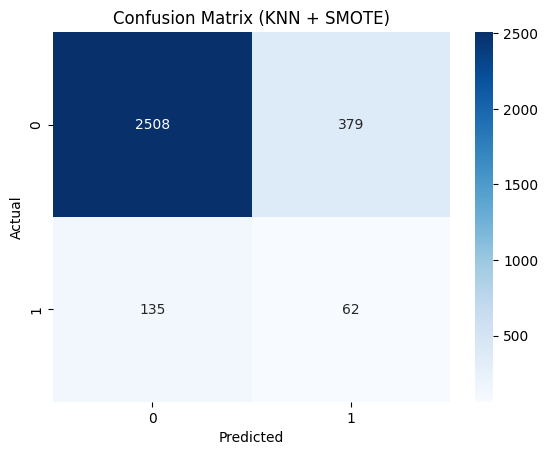

In [ ]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (KNN + SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# apply adasyn

adasyn = ADASYN(random_state=42)

X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

# Check distribution
print("Before ADASYN:\n", y_train.value_counts())
print("\nAfter ADASYN:\n", y_train_ada.value_counts())

Before ADASYN:
 FraudFound_Yes
False    11610
True       726
Name: count, dtype: int64

After ADASYN:
 FraudFound_Yes
True     11777
False    11610
Name: count, dtype: int64


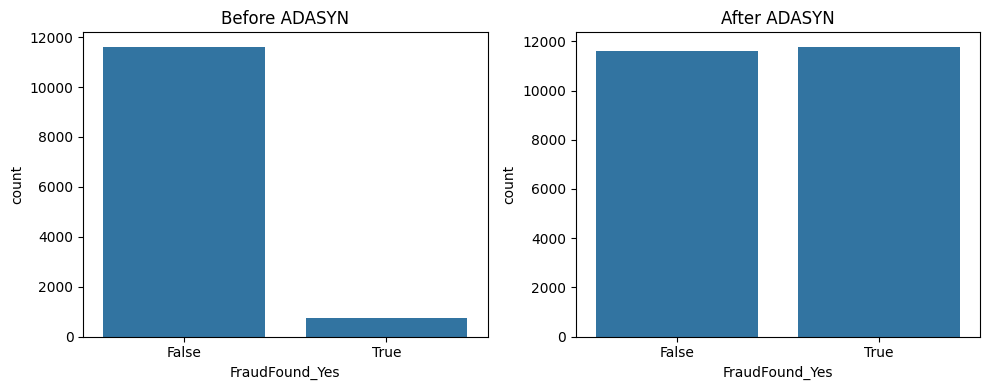

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before ADASYN")

sns.countplot(x=y_train_ada, ax=axes[1])
axes[1].set_title("After ADASYN")

plt.tight_layout()
plt.show()

In [ ]:
# scale

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_ada)
X_test_scaled = scaler.transform(X_test)

In [ ]:
param_dist = {
    'C': [1, 10],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf']
}

random_search = RandomizedSearchCV(
    SVC(probability=False),   # faster
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train_ada)

print("Best Parameters:", random_search.best_params_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
# best model

model = random_search.best_estimator_

In [ ]:
y_pred = model.predict(X_test_scaled)

# Use decision function instead of probability
y_score = model.decision_function(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9293125810635539


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.99      0.96      2887
        True       0.27      0.06      0.10       197

    accuracy                           0.93      3084
   macro avg       0.60      0.52      0.53      3084
weighted avg       0.90      0.93      0.91      3084



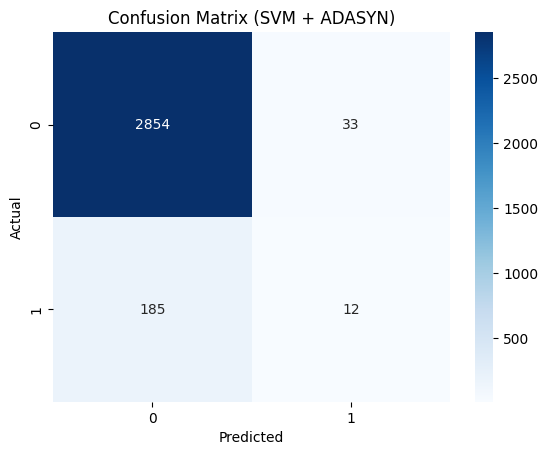

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (SVM + ADASYN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_ada, y_train_ada)

print("Best Parameters:", random_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [ ]:
best_rf = random_search.best_estimator_

In [ ]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9315823605706874


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.99      0.96      2887
        True       0.32      0.06      0.10       197

    accuracy                           0.93      3084
   macro avg       0.63      0.53      0.53      3084
weighted avg       0.90      0.93      0.91      3084



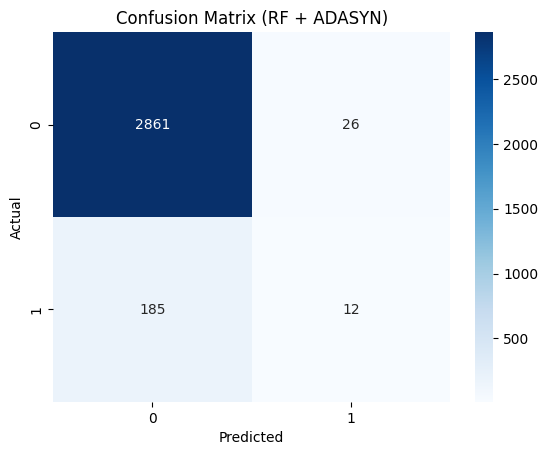

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (RF + ADASYN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_ada)
X_test_scaled = scaler.transform(X_test)

In [ ]:
param_dist = {
    'n_neighbors': [3,5,7,9,11,15,21],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

In [ ]:
knn = KNeighborsClassifier()

random_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train_ada)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'weights': 'distance', 'n_neighbors': 3, 'metric': 'euclidean'}


In [ ]:
best_knn = random_search.best_estimator_

In [ ]:
y_pred = best_knn.predict(X_test_scaled)
y_prob = best_knn.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8369001297016861


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.87      0.91      2887
        True       0.15      0.33      0.21       197

    accuracy                           0.84      3084
   macro avg       0.55      0.60      0.56      3084
weighted avg       0.90      0.84      0.86      3084



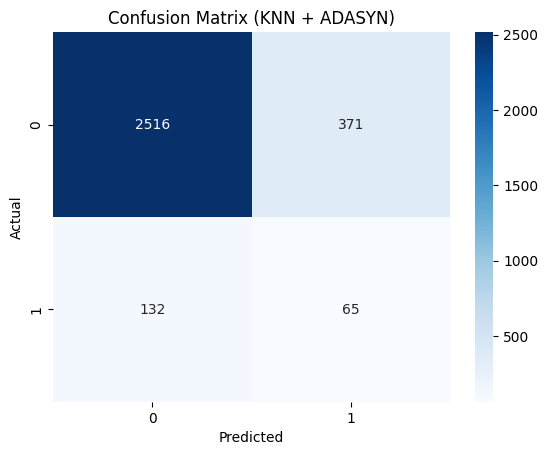

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (KNN + ADASYN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

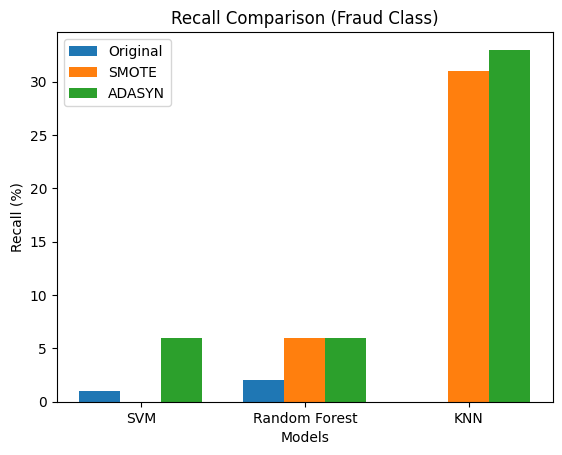

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['SVM', 'Random Forest', 'KNN']

# Recall values (Fraud class)
original = [1, 2, 0]
smote = [0, 6, 31]
adasyn = [6, 6, 33]

x = np.arange(len(models))
width = 0.25

# Plot
plt.figure()
plt.bar(x - width, original, width, label='Original')
plt.bar(x, smote, width, label='SMOTE')
plt.bar(x + width, adasyn, width, label='ADASYN')

# Labels and title
plt.xticks(x, models)
plt.xlabel('Models')
plt.ylabel('Recall (%)')
plt.title('Recall Comparison (Fraud Class)')
plt.legend()

# Show
plt.show()